# ***Testando modelos Baseados em Árvores para predição de geração de energia solar (W/M²) em Fortaleza***



# **Baixar a lib Astral (para pegar mais informações sobre o sol em relação a terra)**

In [158]:
!pip install astral

# **Importar libs**

In [159]:
import kagglehub

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.stats.diagnostic import lilliefors

from datetime import datetime
from astral import Observer
from astral.sun import elevation

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    OneHotEncoder,
    LabelEncoder,
)

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from xgboost import XGBRegressor, XGBRFRegressor, plot_importance

# **Baixar dataset do Kaggle**

In [160]:
path = kagglehub.dataset_download("vagnerhenriques/painel-solar-series-temporais-energia-e-tempo")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'painel-solar-series-temporais-energia-e-tempo' dataset.
Path to dataset files: /kaggle/input/painel-solar-series-temporais-energia-e-tempo


# **Carregar dataset e converter coluna DATETIME para datetime64[ns]**

In [161]:
df = pd.read_csv(path + '/dataresult_en.csv')
df['DATETIME'] = pd.to_datetime(df['DATETIME'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35336 entries, 0 to 35335
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   DATETIME         35336 non-null  datetime64[ns]
 1   IRRADIATION      35336 non-null  int64         
 2   ENVTEMPSTATION   35336 non-null  float64       
 3   WINDSPEED        35336 non-null  float64       
 4   ENVTEMPPANELS    35336 non-null  int64         
 5   POWERFROMPANELS  35336 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(3)
memory usage: 1.6 MB


# **Boxplot para a potencia dos registros com IRRADIATION = 0**

<Axes: ylabel='POWERFROMPANELS'>

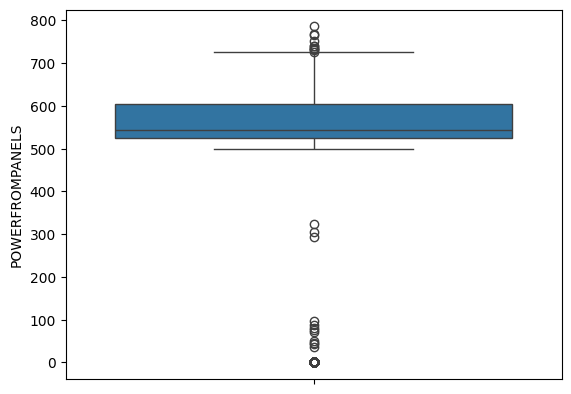

In [162]:
irr_0_power = df[df['IRRADIATION'] == 0]['POWERFROMPANELS']
sns.boxplot(irr_0_power)

# **Indice de Irradiação = 0 com geração de potência maior que 0!!**

- Ruído gerado por falha nos sensores???

# **Boxplot para a potencia dos registros com IRRADIATION = 1**

<Axes: ylabel='POWERFROMPANELS'>

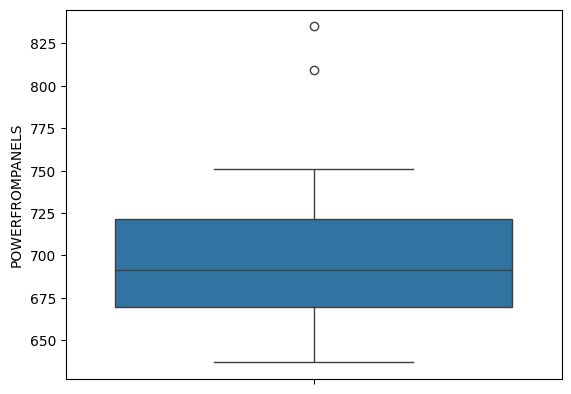

In [163]:
irr_1_power = df[df['IRRADIATION'] == 1]['POWERFROMPANELS']
sns.boxplot(irr_1_power)

# **Boxplot para a potencia dos registros com IRRADIATION = 2**

<Axes: ylabel='POWERFROMPANELS'>

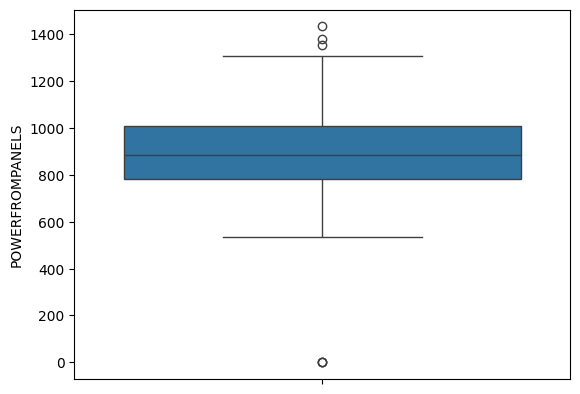

In [164]:
irr_2_power = df[df['IRRADIATION'] == 2]['POWERFROMPANELS']
sns.boxplot(irr_2_power)

# **Indice de irradiação de 0 a 2 possuem distribuições muito parecidas (pode confundir um pouco o modelo)**

In [165]:
# print("\n IRRADIATION = 0 \n")
# display(irr_0_power.describe())

# print("\n IRRADIATION = 1 \n")
# display(irr_1_power.describe())

# print("\n IRRADIATION = 2 \n")
# display(irr_2_power.describe())



print("\n\n --- Teste de Normalidade de Lilliefors (Irradiation = 0 e 2) e Shapiro Wilk (Para Irradiation = 1) ---")

stat_a, p_a = lilliefors(irr_0_power, dist='norm', pvalmethod='table')
print(f"(IRRADIATION = 0): Estatística D = {stat_a:.4f}, p-valor = {p_a:.4e}")

stat_a, p_a = stats.shapiro(irr_1_power)
print(f"(IRRADIATION = 1): Estatística W = {stat_a:.4f}, p-valor = {p_a:.4e}")

stat_a, p_a = lilliefors(irr_2_power, dist='norm', pvalmethod='table')
print(f"(IRRADIATION = 2): Estatística D = {stat_a:.4f}, p-valor = {p_a:.4e}")


print('\n\n --- Comparar variâncias entre as 3 distribuições ---')
levene_test_0_1 = stats.levene(irr_0_power, irr_1_power)
print(f"(0 X 1): Estatística W={levene_test_0_1.statistic:.4f}, p-valor = {levene_test_0_1.pvalue:.4e}")

levene_test_0_2 = stats.levene(irr_0_power, irr_2_power)
print(f"(0 X 2): Estatística W={levene_test_0_2.statistic:.4f}, p-valor = {levene_test_0_2.pvalue:.4e}")

levene_test_0_2 = stats.levene(irr_1_power, irr_2_power)
print(f"(1 X 2): Estatística W={levene_test_0_2.statistic:.4f}, p-valor = {levene_test_0_2.pvalue:.4e}")

print('\n\n --- As 3 distribuições possuem médias diferentes?')
f_stat, p_value = stats.f_oneway(irr_0_power, irr_1_power, irr_2_power)
print(f"F Stat={f_stat:.4f}, p-valor = {p_value:.4e}")



 --- Teste de Normalidade de Lilliefors (Irradiation = 0 e 2) e Shapiro Wilk (Para Irradiation = 1) ---
(IRRADIATION = 0): Estatística D = 0.3809, p-valor = 1.0000e-03
(IRRADIATION = 1): Estatística W = 0.9185, p-valor = 3.1764e-02
(IRRADIATION = 2): Estatística D = 0.0525, p-valor = 1.0000e-03


 --- Comparar variâncias entre as 3 distribuições ---
(0 X 1): Estatística W=5.1300, p-valor = 2.3626e-02
(0 X 2): Estatística W=7.0716, p-valor = 7.8709e-03
(1 X 2): Estatística W=26.3351, p-valor = 3.3177e-07


 --- As 3 distribuições possuem médias diferentes?
F Stat=1798.9423, p-valor = 0.0000e+00


**Resultados dos testes estatisticos:**
 - Normalidade confirmada;
 - Variâncias parecidas entre os 3 grupos;
 - Médias diferentes.

# **Corrigir inconsistências nos dados (Erros de sensor)**

In [166]:
df.loc[
    (df["IRRADIATION"] == 0)
    & (df["POWERFROMPANELS"] <= irr_1_power.max())
    & (df["POWERFROMPANELS"] > 0),
    "IRRADIATION",
] = 1

df.loc[((df['POWERFROMPANELS'] == 0) & (df['IRRADIATION'] > 0)), 'POWERFROMPANELS'] = np.nan

# **Resgatar ângulo solar das observações**

In [167]:
latitude = -3.7304512
longitude = -38.5217989

def solar_angle(dt: datetime):

    observer = Observer(
        latitude=latitude,
        longitude=longitude
    )

    return elevation(observer, dt)

df['solar_angle'] = df.apply(
    lambda row: solar_angle(
        row["DATETIME"]
    ),
    axis=1
)

df['has_daylight'] = df.apply(
    lambda row: 1 if (row["solar_angle"] > 0) and (row['POWERFROMPANELS'] > 0) else 0,
    axis=1
)

df['has_daylight'].value_counts()

,count
has_daylight,
1,27408
0,7928


# Remover registros inválidos

In [168]:
df.dropna(inplace=True)

# **Transformação Senoidal e Cossenoidal (Mês e Hora do dia)**

In [169]:
df['MONTH_SIN'] = np.sin((2 * np.pi * df['DATETIME'].dt.month) / 12)
df['MONTH_COS'] = np.cos((2 * np.pi * df['DATETIME'].dt.month) / 12)
df['DAY_SIN'] = np.sin((2 * np.pi * df['DATETIME'].dt.day) / 365)
df['DAY_COS'] = np.cos((2 * np.pi * df['DATETIME'].dt.day) / 365)
df['HOUR_SIN'] =  np.sin((2 * np.pi * df['DATETIME'].dt.hour) / 24)
df['HOUR_COS'] =  np.cos((2 * np.pi * df['DATETIME'].dt.hour) / 24)

# **Método para resumir métricas de regressão linear**

In [170]:
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R²": r2_score(y_true, y_pred),
    }

# **Correlação: Pearson e Spearman**

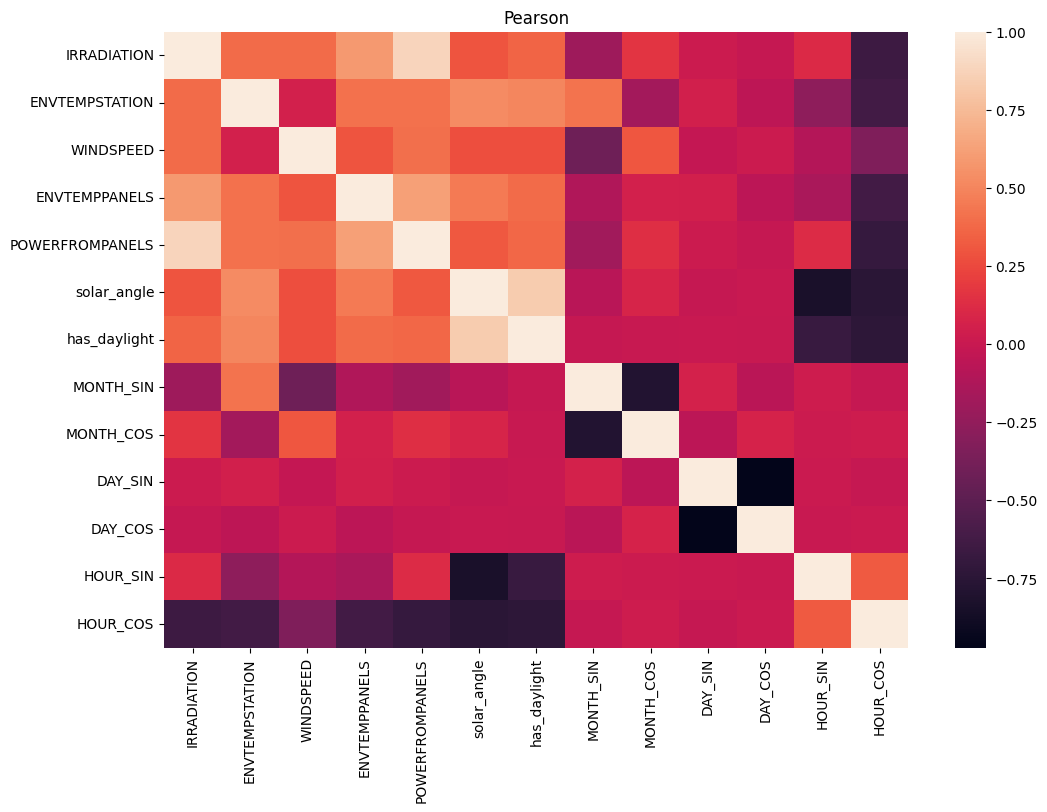

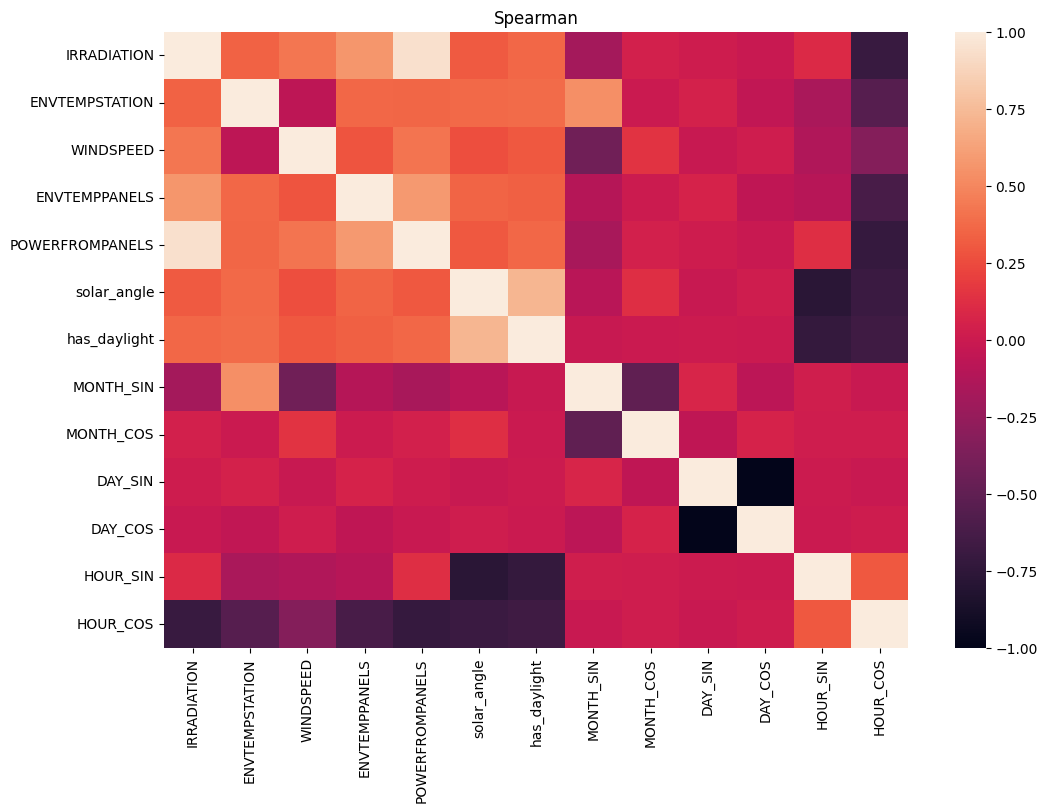

In [171]:
num_features = df.select_dtypes(include='number')

corr_pearson = num_features.corr()
corr_spearman = num_features.corr('spearman')

plt.figure(figsize=(12,8))
sns.heatmap(corr_pearson)
plt.title("Pearson")
plt.show()

plt.figure(figsize=(12,8))
sns.heatmap(corr_spearman)
plt.title("Spearman")
plt.show()

# **Definir features e target**

In [172]:
X = df.drop(columns=['DATETIME', 'POWERFROMPANELS'])
y = df['POWERFROMPANELS']

# **Testando Modelos baseados em Árvores + Métricas + Gráficos de dispersão**


 Treinando Decision Tree...

=== Teste - Metricas ===
MAE: 3175.6107
MSE: 59284511.8575
RMSE: 7699.6436
R²: 0.7813

 Treinando XGBoost...

=== Teste - Metricas ===
MAE: 2846.6273
MSE: 33968739.4193
RMSE: 5828.2707
R²: 0.8747

 Treinando Random Forest...

=== Teste - Metricas ===
MAE: 2688.6313
MSE: 37148743.9388
RMSE: 6094.9769
R²: 0.8630


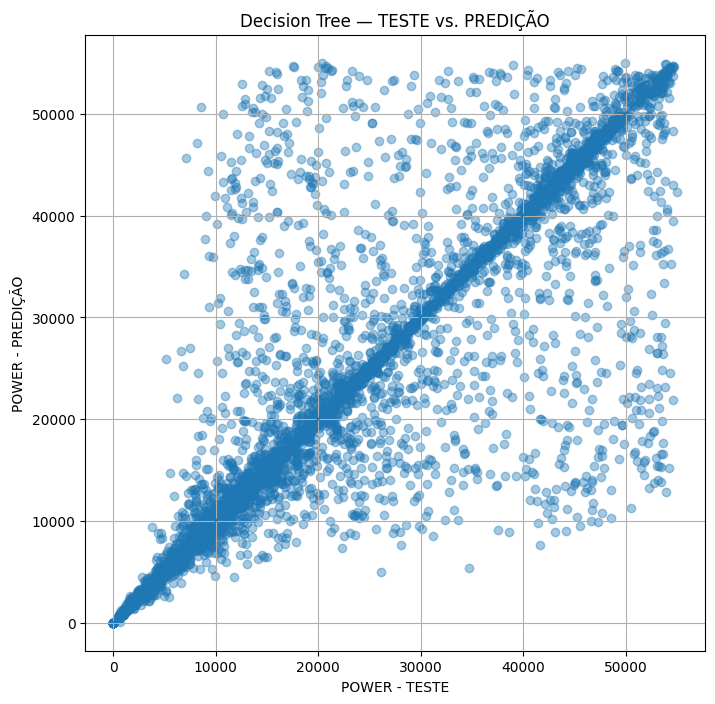

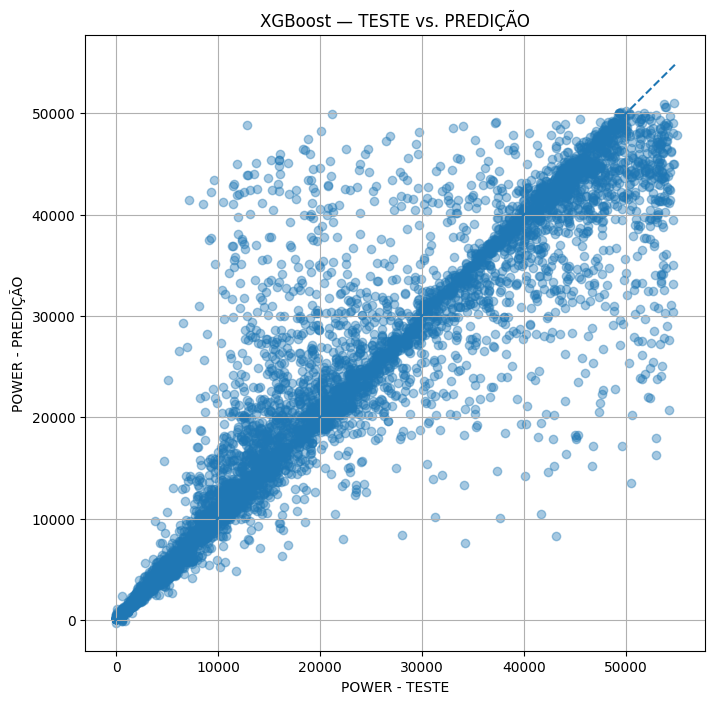

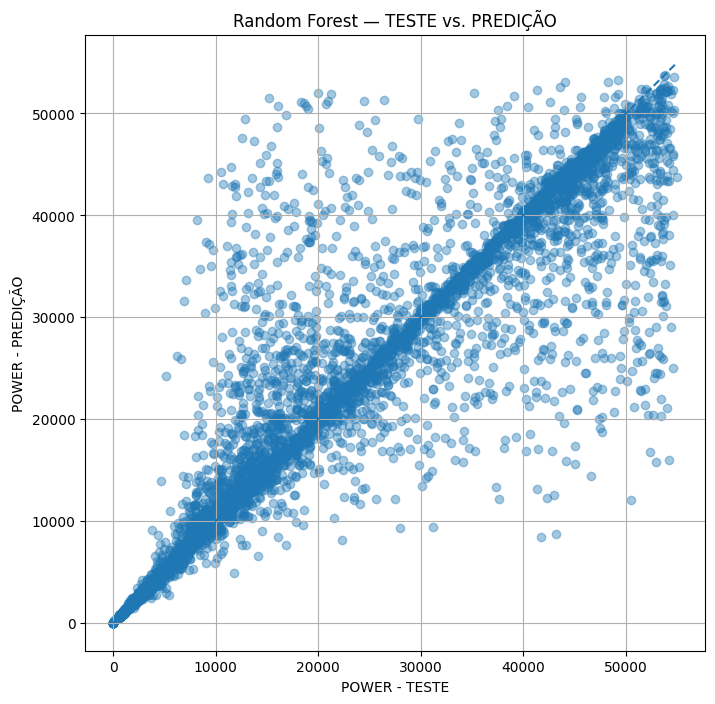

In [173]:
models = {
    'Decision Tree': Pipeline([
        ('model', DecisionTreeRegressor(random_state=42))
    ]),
    'XGBoost': Pipeline([
        ('model', XGBRegressor(
            n_estimators=300,
            learning_rate= 0.03,
            max_depth=None,
            objective='reg:squarederror',
            random_state=42
        ))
    ]),
    'Random Forest': Pipeline([
        ('model', RandomForestRegressor(100, random_state=42))
    ])
}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

for name, model in models.items():
  print(f"\n Treinando {name}...")
  model.fit(X_train, y_train)

  y_test_pred = model.predict(X_test)

  test_metrics = regression_metrics(y_test, y_test_pred)


  print("\n=== Teste - Metricas ===")
  for metric, value in test_metrics.items():
      print(f"{metric}: {value:.4f}")

  y_test_array = np.asarray(y_test).ravel()
  y_pred_array = np.asarray(y_test_pred).ravel()

  plt.figure(figsize=(8, 8))

  plt.scatter(
      y_test_array,
      y_pred_array,
      alpha=0.4
  )

  min_value = min(y_test_array.min(), y_pred_array.min())
  max_value = max(y_test_array.max(), y_pred_array.max())

  plt.plot(
      [min_value, max_value],
      [min_value, max_value],
      linestyle="--"
  )

  plt.xlabel("POWER - TESTE")
  plt.ylabel("POWER - PREDIÇÃO")
  plt.title(f"{name} — TESTE vs. PREDIÇÃO")
  plt.grid(True)

plt.show()

# **XGBoost - Importance Score das features**

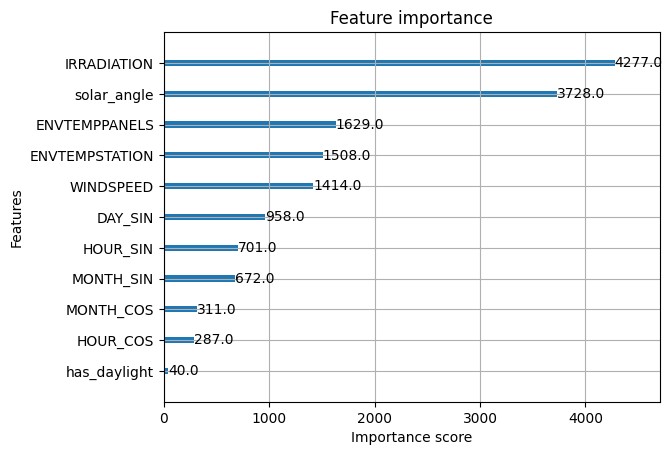

In [174]:
plot_importance(models.get('XGBoost')[0])
plt.show()

# **Resultados**

- Até o momento, o ***XGBoost*** e o ***Random Forest*** se mostraram algoritmos muito bons para a previsão de potência em Watts gerada pelos painéis solares, com base nas informações fornecidas pelos sensores;

- O ***XGBoost*** se mostrou o modelo mais equilibrado, com ótimas métricas para:   
  - Erro Médio Absoluto;
  - Erro Quadrático Médio;
  - Raiz do Erro Quadrático Médio;
  - R² Score.

- O ***Random Forest*** gerou a melhor métrica para Erro Médio Absoluto;

- As falhas nos sensores podem ter gerado mais ruídos nos dados que eu não pude resolver (acho que eu nem deveria).